In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("loan_approval_dataset.csv")
df.columns=df.columns.str.strip()
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df["loan_status"].isnull().sum())
print(df["loan_status"].unique())
df["loan_status"] = df["loan_status"].str.strip().str.capitalize()

   loan_id  no_of_dependents      education self_employed  income_annum  \
0        1                 2       Graduate            No       9600000   
1        2                 0   Not Graduate           Yes       4100000   
2        3                 3       Graduate            No       9100000   
3        4                 3       Graduate            No       8200000   
4        5                 5   Not Graduate           Yes       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value loan_status  
0                 17600000             22700000           80

In [ ]:
df["loan_status"]=df["loan_status"].map({"Approved":1,"Rejected":0})
df["education"]=df["education"].map({"Graduate":1 , "NotGraduate":0})
df["self_employed"]=df["self_employed"].map({"Yes":1, "No":0})

In [ ]:
df["total_assets"]=(df["residential_assets_value"]+df["commercial_assets_value"]+df["luxury_assets_value"]+df["bank_asset_value"])
df["loan_income_ratio"] = df["loan_amount"] / df["income_annum"]

In [ ]:
X=df.drop("loan_status",axis=1)
y=df["loan_status"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
res=model.predict(X_test)
print("Confusion_matrix:\n",confusion_matrix(y_test,res))
print("classification_report:\n:",classification_report(y_test,res))
print("Accuracy of this model is:\n",accuracy_score(y_test,res))

Confusion_matrix:
 [[317   1]
 [  0 536]]
classification_report:
:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       318
           1       1.00      1.00      1.00       536

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

Accuracy of this model is:
 0.9988290398126464


In [ ]:
from sklearn.tree import DecisionTreeClassifier
Dt=DecisionTreeClassifier()
Dt.fit(X_train,y_train)
res1=Dt.predict(X_test)
print("Confusion_matrix:\n",confusion_matrix(y_test,res1))
print("classification_report:\n:",classification_report(y_test,res1))
print("Accuracy of this model is:\n",accuracy_score(y_test,res1))


Confusion_matrix:
 [[317   1]
 [  2 534]]
classification_report:
:               precision    recall  f1-score   support

           0       0.99      1.00      1.00       318
           1       1.00      1.00      1.00       536

    accuracy                           1.00       854
   macro avg       1.00      1.00      1.00       854
weighted avg       1.00      1.00      1.00       854

Accuracy of this model is:
 0.9964871194379391


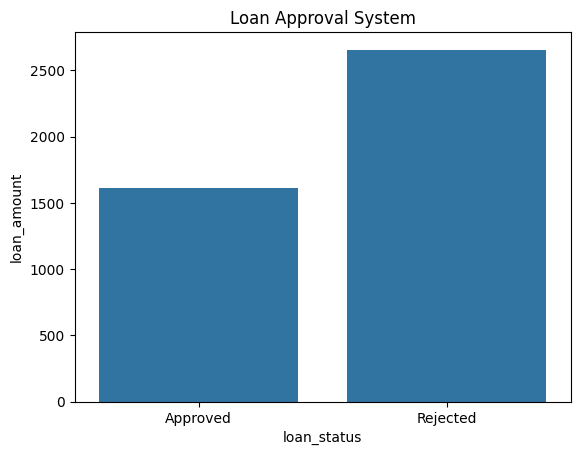

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
res2=df["loan_status"]
sns.countplot(x=res2)
plt.xticks([0,1], ["Approved", "Rejected"])
plt.title("Loan Approval System")
plt.xlabel("loan_status")
plt.ylabel("loan_amount")
plt.show()